# BINF TP8 Alignement sur génome de référence - Algorithme bowtie et transformée de Burrows-Wheeler

On cherche à reconstruire le génome d'un organisme dont l'espèce a déjà été séquencé. On va utiliser le génome existant pour guider notre reconstruction en cherchant la position de chaque fragment séquencé dans le génome de référence.

On appelle read un fragment séquencé. La taille d'un read dépend de la mêthode de séquençage. La méthode de Sanger produit des reads d'environ 1000 nucléotides alors que les méthodes de séquençage nouvelle génération vont avoir des reads plus courts d'environ 100 nucléotides.

Les génomes ayant des tailles de l'ordre de 100 000 paires de bases et plus, leur séquençage requiert l'acquisition de milliers voirs millions de reads dont il faut trouver la position dans le génome de référence. Pour que cette méthode soit viable, il faut être capable d'effectuer cette recherche de manière efficace.

La méthode bowtie propose une solution à ce problème basé sur le calcul de la tranformée de Burrows-Wheeler du génome de référence. La transformée de Burrow-Wheeler est une structure basée sur l'ordonancement des préfixes / suffixes d'une séquence permettant une recherche efficace de sous-séquence. Pour pouvoir faire le lien entre transformée et séquence d’origine, on va aussi calculer un index faisant la correspondance entre un caractère de la séquence transformée et la position d’apparition du préfixe correspondant.

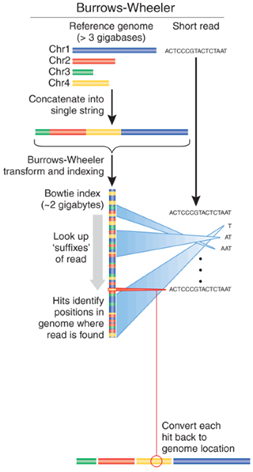

## Exercice 1 : Transformée de Burrows-Wheeler

La transformée de Burrows-Wheeler (BWT) s'obtient en triant par ordre lexicographique toutes les permutations circulaires possibles d'une séquence, et en conservant le dernier caractère de chacune.

Ecrire la fonction BWT(s) -> str qui retourne la transformée BW de la séquence s en effectuant les étapes suivantes :


1. Ajouter un caractère $ à la fin de s (celui-ci servira pour la transformée inverse).
2. Générer la liste perm toutes les permutations circulaires de s (on fait passer la dernière lettre au début de s).
3. Générer un tableau d'indice qui contient l'ordre de chaque permutation.
4. Trier le tableau d'indices et perm par ordre lexicographique de perm.
5. Retourner la séquence contenant le dernier caractère de chaque permutation dans l'ordre lexicographique ainsi que le tableau d'indices.


In [ ]:
print("Votre code ici.")

### Exemple

Transformée de chien :

* Ajouter un caractère \\$ à la fin : chien$

* Générer le tableau perm des permutations cirulaires :

$$
\begin{array}{cc}
Permutations & Indices\\
chien$ & 0\\
$chien & 1\\
n$chie & 2\\
en$chi & 3\\
ien$ch & 4\\
hien$c & 5
\end{array}
$$
* Trier ce tableau par ordre lexicographique :
$$
\begin{array}{cc}
Permutations & Indices\\
$chien & 1\\
chien$ & 0\\
en$chi & 3\\
hien$c & 5\\
ien$ch & 4\\
n$chie & 2
\end{array}
$$
* La transformée est la dernière colonne de ce tableau (le dernier caractère pour chaque ligne) : n$iche et la liste des indices est [1, 0, 3, 5, 4, 2]

## Exercice 2 : Transformée inverse

Pour vérifier que la transformée est correcte, on va implémenter la transformée inverse. Pour ce faire, on va recréer l’ensemble des permutations de manière itérative en faisant un nombre d’itérations égal à la taille de la transformée. On va commencer avec un ensemble de séquences vides qu’on appelle table de même taille que la transformée qu’on va modifier à chaque itération :

* Pour chaque caractère en position i de la transformee, l’ajouter au début de la ième séquence de table.
* Trier table par ordre lexicographique.

Le résultat est la séquence de table qui se termine par le caractère $. Notez que c’est pour ça qu’on a besoin d’ajouter ce caractère au moment de la transformée.

Ecrivez la fonction iBWT(t) -> str qui retourne la transformée inverse de la transformée BW t.


In [ ]:
print("Votre code ici")

### Exemple :
Transformée inverse de n$iche :

$$
\begin{array}{lllllllllll}
ADD1 & SORT1 & ADD2 & SORT2 & ADD3 & SORT3 & ADD4 & SORT4 & ADD5 & SORT5 & ADD6\\
n & $ & n$ & $c & n$c & $ch & n$ch & $chi & n$chi & $chie & n$chie\\
$ & c & $c & ch & $ch & chi & $chi & chie & $chie & chien  & $chien\\
i & e & ie & en & ien & en$ & ien$ & en$c & ien$c & en$ch & ien$ch\\
c & h & ch & hi & chi & hie & chie & hien & chien & hien$ & chien$\\
h & i & hi & ie & hie & ien & hien & ien$ & hien & ien$c & ien$c\\
e & n & en & n$ & en$ & n$c & en$c & n$ch & en$ch & n$chi & en$chi\\
\end{array}
$$


## Exercice 3 : Recherche d'un mot dans la transformée


### Etape préliminaire 1

Pour pouvoir rechercher efficacement dans la transformée on va avoir besoin de calculer pour chaque caractère le nombre d'occurences de caractères qui lui sont lexicographiquement inférieur dans la transformée.

Ecrire la fonction compute_C(s) -> dict qui retourne un dictionnaire contenant pour chaque caractère le nombres de caractères qui lui sont lexicographiquement inférieur dans s.

In [ ]:
print("Votre code ici.")

Par exemple, pour n$iche on a:

$$
\begin{array}{lll}
$ & \rightarrow & 0\\
c & \rightarrow & 1\\
e & \rightarrow & 2\\
h & \rightarrow & 3\\
i & \rightarrow & 4\\
n & \rightarrow & 5
\end{array}
$$

### Etape préliminaire 2

Il nous faut aussi créer une fonction qui calcule le nombre d'occurence d'un caractère dans la transformée jusqu'à une certaine position non inclue.

Ecrivez la fonction occ(c,s,k) -> int qui retourne le nombre d'occurence du caractère $c$ dans la transformée $s$ jusqu'à la position $k$ non inclue.

In [1]:
print("Votre code ici.")

Votre code ici.


### Algorithme de recherche

On détermine itérativement l'ensemble des lignes de la table contenant des fragments de plus en plus longs du mot recherché, jusqu'à obtenir l'ensemble des lignes contenant le mot entier. Vu que la table est toujours triée lexicographiquement, on sait que ces séquences vont se trouver côte à côte.

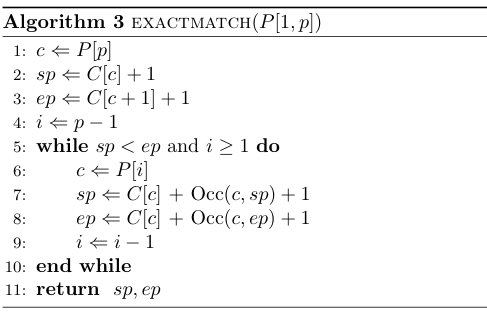


Ou $P$ est la séquence recherchée de taille $p$, et $C$ et $occ(c,k)$ ont été définies dans les étapes préliminaires ci-dessus.

Les indices $sp$ et $ep$ délimitent respectivement le début et la fin des lignes contenant $P$ dans la transformée. Si $P$ est présente, alors elle apparâit dans toutes les séquences entre les indices $sp$ et $ep$. Le tableau $C$ peut être précalculé. **Attention dans l'algorithme ci-dessus les indices commencent à 1.**

Finalement, on va étendre l'algorithme présenté ci-dessus pour rentourner tous les indices entre $sp$ et $ep$ à partir du tableau d'indice de la transformée.
Souvenez vous que les indices de la transformé ne correspondent pas directement à une position dans la séquence, pour celà, il faut se réferrer au tableau d'indices généré lors de la transformé.

Ecrivez la fonction exactmatch(p, s, idxs) -> list qui retourne la liste des indices de départ de la séquence $p$ dans la transformée $s$ basé sur le tableau d'indices $idxs$.

In [ ]:
print("Votre code ici !")